# 03 — Feature Engineering

**Purpose:** Build all transaction-level and customer-level behavioral features.
Validate point-in-time safety. Assemble the final feature matrix for the classifier.
Persist everything to `data/processed/`.

**Key principle:** All customer history features (return rate, velocity, RFM) are computed
using only transactions **before** the current transaction's invoice date — no lookahead leakage.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (12, 5), 'figure.dpi': 110,
    'axes.facecolor': '#1a1d27', 'figure.facecolor': '#0f1117',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#e8eaf0',
    'xtick.color': '#8b92a8', 'ytick.color': '#8b92a8',
    'text.color': '#e8eaf0', 'grid.color': '#2e3347', 'grid.alpha': 0.5,
})

from src.features import (
    load_raw, add_transaction_features,
    build_customer_features, add_return_velocity,
    build_category_return_rates, build_feature_matrix
)
print('Imports OK')

Imports OK


## 1. Load and clean raw data

In [2]:
df = load_raw('../data/raw/online_retail_II.xlsx')

# Drop zero/negative price rows (ambiguous data, not returns)
n_before = len(df)
df = df[df['unit_price'] >= 0].copy()
print(f'Dropped {n_before - len(df):,} negative-price rows')
print(f'Working dataset: {len(df):,} rows')
print(f'Returns: {df.is_return.sum():,} ({df.is_return.mean():.1%})')

Dropped 5 negative-price rows
Working dataset: 1,067,366 rows
Returns: 19,494 (1.8%)


## 2. Transaction-level features

In [3]:
df = add_transaction_features(df)

tx_features = ['unit_price_z', 'quantity_z', 'is_weekend', 'month_end_proximity', 'revenue']
print('Transaction feature stats:')
print(df[tx_features].describe().round(3).to_string())

Transaction feature stats:
       unit_price_z  quantity_z   is_weekend  month_end_proximity      revenue
count   1066933.000  824218.000  1067366.000          1067366.000  1067366.000
mean          0.000       0.000        0.131               15.334       18.219
std           0.997       0.996        0.337                8.747      281.688
min         -46.872     -27.096        0.000                0.000  -168469.600
25%          -0.504      -0.483        0.000                8.000        3.750
50%          -0.344      -0.248        0.000               15.000        9.900
75%          -0.009       0.169        0.000               23.000       17.700
max          32.058      44.803        1.000               30.000   168469.600


## 3. Customer-level behavioral features

**Point-in-time safety:** Using `as_of_date=None` here computes features over the full dataset
for the static feature table (API serving). The backtesting notebook (08) calls
`build_customer_features(as_of_date=window_end)` for strict temporal correctness.

In [4]:
customer_features = build_customer_features(df)
customer_features = add_return_velocity(df, customer_features)

print(f'Customer features: {len(customer_features):,} customers × {len(customer_features.columns)} columns')
print()
print('Behavioral feature stats:')
feat_cols = [
    'lifetime_return_rate', 'return_value_ratio', 'return_velocity',
    'tenure_days', 'recency_score', 'frequency_score', 'monetary_score',
    'unique_categories_returned', 'weekend_return_share'
]
print(customer_features[feat_cols].describe().round(3).to_string())

Customer features: 5,881 customers × 18 columns

Behavioral feature stats:
       lifetime_return_rate  return_value_ratio  return_velocity  tenure_days  recency_score  frequency_score  monetary_score  unique_categories_returned  weekend_return_share
count              5881.000            5881.000         5881.000     5881.000       5881.000         5881.000        5881.000                    5881.000              5881.000
mean                  0.193               0.033            0.074      473.698        200.458            6.287        3017.077                       2.613                 0.053
std                   0.335               0.141            0.336      223.150        209.474           13.013       14734.129                       7.946                 0.442
min                   0.000               0.000            0.000        0.000          0.000            1.000           0.000                       0.000                 0.000
25%                   0.000               0.0

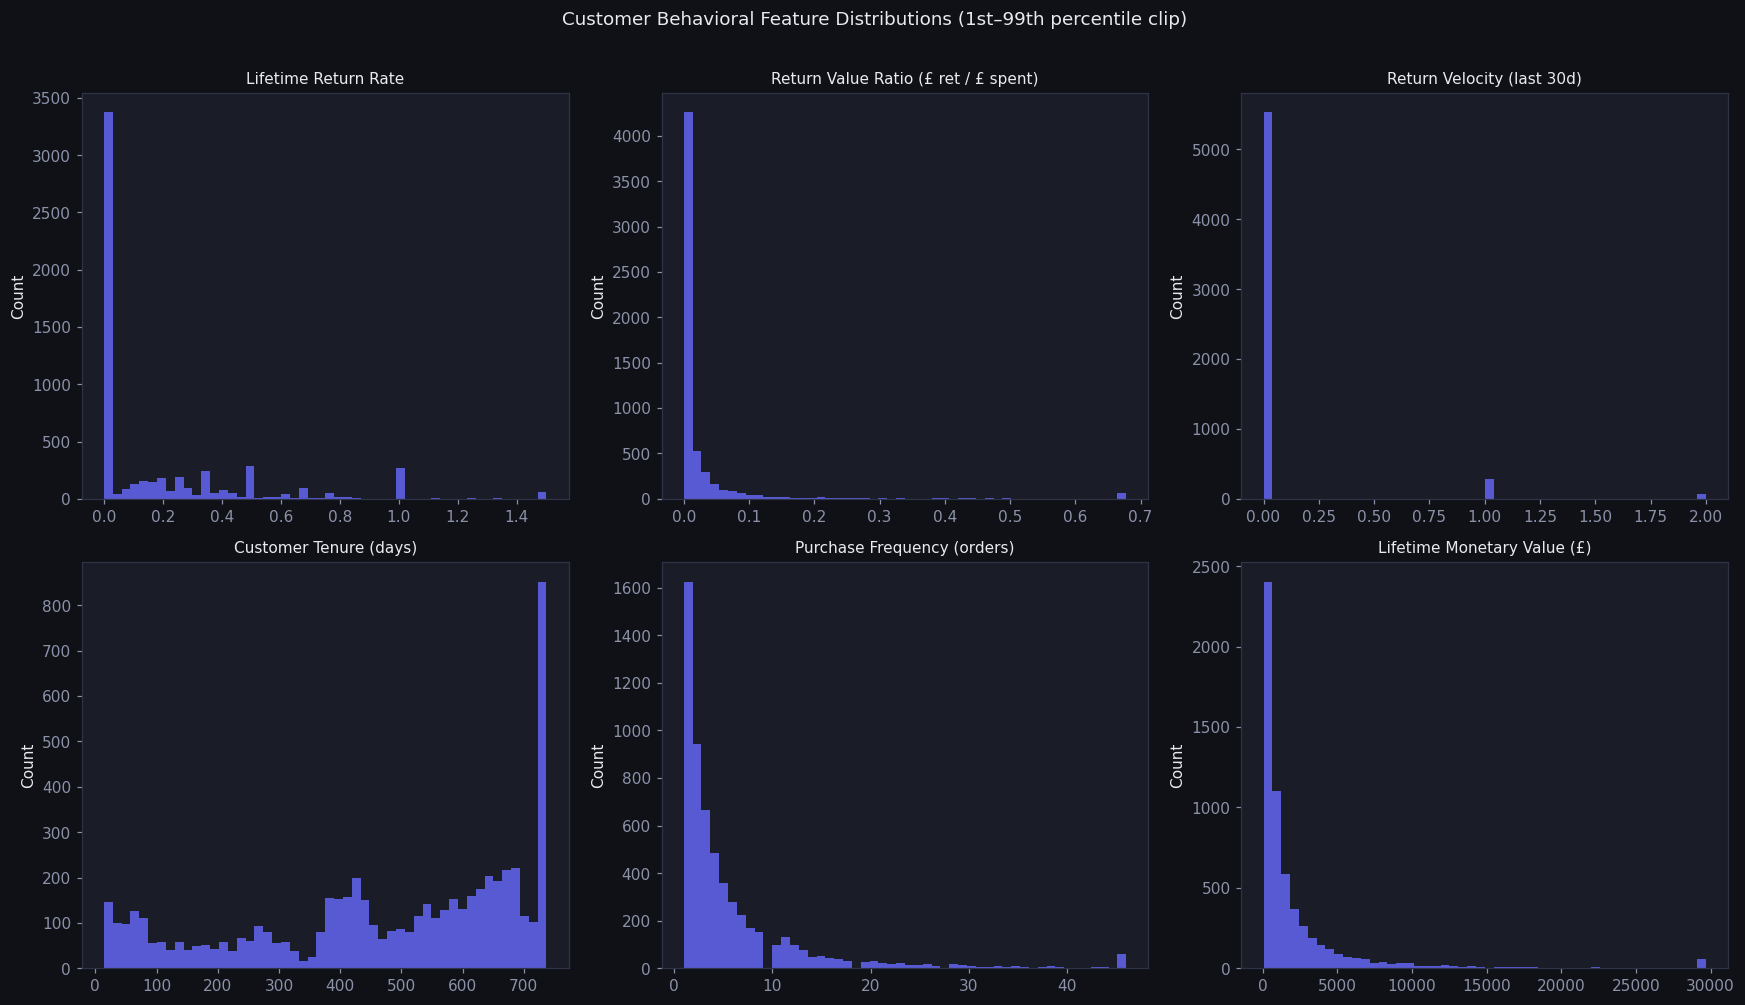

In [5]:
# Distribution plots for key behavioral features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plot_features = [
    ('lifetime_return_rate', 'Lifetime Return Rate'),
    ('return_value_ratio', 'Return Value Ratio (£ ret / £ spent)'),
    ('return_velocity', 'Return Velocity (last 30d)'),
    ('tenure_days', 'Customer Tenure (days)'),
    ('frequency_score', 'Purchase Frequency (orders)'),
    ('monetary_score', 'Lifetime Monetary Value (£)'),
]

for ax, (col, title) in zip(axes, plot_features):
    data = customer_features[col].clip(
        customer_features[col].quantile(0.01),
        customer_features[col].quantile(0.99)
    )
    ax.hist(data, bins=50, color='#6366f1', edgecolor='none', alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Count')

plt.suptitle('Customer Behavioral Feature Distributions (1st–99th percentile clip)', y=1.01, fontsize=12)
plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/03_feature_distributions.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 4. Category return rates

In [6]:
category_rates = build_category_return_rates(df)
print(f'Category return rates: {len(category_rates):,} stock codes')
print(f'Mean category return rate: {category_rates.category_return_rate.mean():.1%}')
print(f'Max category return rate:  {category_rates.category_return_rate.max():.1%}')
category_rates.sort_values('category_return_rate', ascending=False).head(10)

Category return rates: 5,304 stock codes
Mean category return rate: 2.1%
Max category return rate:  100.0%


,stock_code,category_return_rate
785,21315,1.000000
815,21346,1.000000
1188,21766,1.000000
5249,CRUK,1.000000
3710,79340P,1.000000
341,20779,1.000000
5250,D,0.971751
5290,S,0.971154
5244,AMAZONFEE,0.906977
3711,79340W,0.833333


## 5. Assemble feature matrix and temporal split

Train on Dec 2009 – Jun 2011 (18 months), test on Jul 2011 – Dec 2011 (6 months).
This matches the backtesting protocol — no future data leaks into training.

In [7]:
CUTOFF = pd.Timestamp('2011-07-01')

train_df = df[df['invoice_date'] < CUTOFF].copy()
test_df  = df[df['invoice_date'] >= CUTOFF].copy()

# For train, use customer features computed on train data only (strict temporal split)
train_cust = build_customer_features(train_df)
train_cust = add_return_velocity(train_df, train_cust)
train_cat  = build_category_return_rates(train_df)

# For test, use full-dataset customer features (simulates API serving)
X_train, y_train = build_feature_matrix(train_df, train_cust, train_cat)
X_test,  y_test  = build_feature_matrix(test_df,  customer_features, category_rates)

print(f'Train: {len(X_train):,} rows, {len(X_train.columns)} features, {y_train.mean():.1%} return rate')
print(f'Test:  {len(X_test):,}  rows, {len(X_test.columns)}  features, {y_test.mean():.1%} return rate')
print(f'\nFeature columns: {X_train.columns.tolist()}')

Train: 771,361 rows, 14 features, 1.9% return rate
Test:  296,005  rows, 14  features, 1.6% return rate

Feature columns: ['unit_price_z', 'quantity_z', 'is_weekend', 'month_end_proximity', 'lifetime_return_rate', 'return_value_ratio', 'return_velocity', 'tenure_days', 'recency_score', 'frequency_score', 'monetary_score', 'unique_categories_returned', 'weekend_return_share', 'category_return_rate']


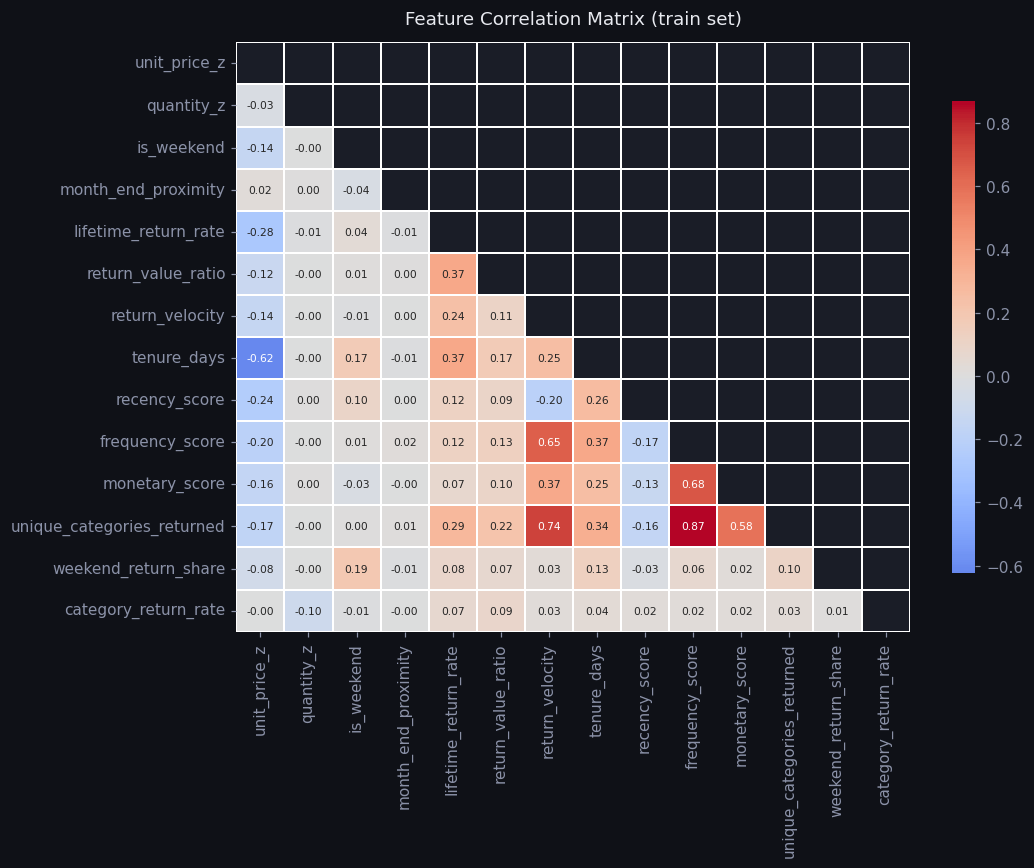

In [8]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix (train set)', pad=12)
plt.tight_layout()
plt.savefig('../figures/03_feature_correlation.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 6. Persist features to disk

In [ ]:
os.makedirs('../data/processed', exist_ok=True)

# Cast mixed-type columns to string before parquet serialisation
category_rates = category_rates.copy()
category_rates['stock_code'] = category_rates['stock_code'].astype(str)

# Ensure customer_id is string (UCI II sometimes returns it as float)
customer_features = customer_features.copy()
customer_features['customer_id'] = customer_features['customer_id'].astype(str)

# Full feature matrices (all numeric — safe for parquet)
X_train.assign(is_return=y_train.values).to_parquet('../data/processed/train_features.parquet', index=False)
X_test.assign(is_return=y_test.values).to_parquet('../data/processed/test_features.parquet', index=False)

# Customer features (needed by API at serving time)
customer_features.to_parquet('../data/processed/customer_features.parquet', index=False)
category_rates.to_parquet('../data/processed/category_return_rates.parquet', index=False)

print('Persisted to data/processed/:')
for f in sorted(os.listdir('../data/processed')):
    size_kb = os.path.getsize(f'../data/processed/{f}') / 1024
    print(f'  {f:<45} {size_kb:,.0f} KB')

Persisted to data/processed/:
  category_return_rates.parquet                 50 KB
  customer_features.parquet                     335 KB
  customer_return_ranks.parquet                 61 KB
  eda_summary.json                              0 KB
  return_velocity.parquet                       15 KB
  rfm_features.parquet                          93 KB
  test_features.parquet                         2,003 KB
  train_features.parquet                        4,982 KB
